<a href="https://colab.research.google.com/github/sriramragam-rgb/Hospital_ward_staffing_optimizer/blob/main/Hospital_ward_staff_optimize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# HOSPITAL WARD STAFFING OPTIMIZER
# B.Tech Mathematics Mini Project - A1
# Mathematical Concept: System of Linear Equations
# Method: Gaussian Elimination
# ============================================================

print("=" * 65)
print("       HOSPITAL WARD STAFFING OPTIMIZER")
print("                 B.Tech Mini Project")
print("=" * 65)

       HOSPITAL WARD STAFFING OPTIMIZER
                 B.Tech Mini Project


In [ ]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ============================================================
# CELL 3: USER CONFIGURATION
# ============================================================

# Names of wards
wards = ["Ward A", "Ward B", "Ward C"]

# Names of staff types
staff_types = ["Senior Nurse", "Junior Nurse", "Assistant"]

# Required total staff-hours for each ward
required_hours = np.array([
    20,   # Ward A
    25,   # Ward B
    15    # Ward C
], dtype=float)

# Cost per hour for each staff type
staff_costs = np.array([
    800,   # Senior Nurse
    400,   # Junior Nurse
    200    # Assistant
], dtype=float)

# ------------------------------------------------------------
# HOURS CONTRIBUTION MATRIX
#
# Rows    -> Wards
# Columns -> Staff types
#
#             Senior   Junior   Assistant
# Ward A         1        2         3
# Ward B         2        3         1
# Ward C         1        1         2
# ------------------------------------------------------------

hours_matrix = np.array([
    [1, 2, 3],
    [2, 3, 1],
    [1, 1, 2]
], dtype=float)

print("Input data loaded successfully.")

Input data loaded successfully.


In [ ]:
# ============================================================
# CELL 4: DISPLAY INPUT DATA
# ============================================================

input_table = pd.DataFrame(
    hours_matrix,
    index=wards,
    columns=staff_types
)

input_table["Required Staff-Hours"] = required_hours

print("\nStaff contribution matrix:")
display(input_table)

print("\nStaff cost per hour:")

cost_table = pd.DataFrame({
    "Staff Type": staff_types,
    "Cost per Hour (Rs.)": staff_costs
})

display(cost_table)


Staff contribution matrix:


,Senior Nurse,Junior Nurse,Assistant,Required Staff-Hours
Ward A,1.0,2.0,3.0,20.0
Ward B,2.0,3.0,1.0,25.0
Ward C,1.0,1.0,2.0,15.0



Staff cost per hour:


,Staff Type,Cost per Hour (Rs.)
0,Senior Nurse,800.0
1,Junior Nurse,400.0
2,Assistant,200.0


In [ ]:
# ============================================================
# CELL 5: INPUT VALIDATION
# ============================================================

if hours_matrix.shape != (3, 3):
    raise ValueError("The hours matrix must contain 3 wards and 3 staff types.")

if len(required_hours) != 3:
    raise ValueError("Exactly 3 ward requirements are required.")

if len(staff_costs) != 3:
    raise ValueError("Exactly 3 staff costs are required.")

if np.any(hours_matrix <= 0):
    raise ValueError("Hours contribution values must be positive.")

if np.any(required_hours <= 0):
    raise ValueError("Required hours must be positive.")

if np.any(staff_costs <= 0):
    raise ValueError("Staff costs must be positive.")

print("✓ All inputs are valid.")

✓ All inputs are valid.


In [ ]:
# ============================================================
# CELL 6: CONSTRUCT AX = B
# ============================================================

A = sp.Matrix(hours_matrix)
B = sp.Matrix(required_hours)

# Unknown staffing variables
S, J, As = sp.symbols("S J As")

X = sp.Matrix([
    S,
    J,
    As
])

print("Matrix A:")
sp.pprint(A)

print("\nVector X:")
sp.pprint(X)

print("\nVector B:")
sp.pprint(B)

print("\nTherefore, our mathematical model is:")
print("A × X = B")

Matrix A:
⎡1.0  2.0  3.0⎤
⎢             ⎥
⎢2.0  3.0  1.0⎥
⎢             ⎥
⎣1.0  1.0  2.0⎦

Vector X:
⎡S ⎤
⎢  ⎥
⎢J ⎥
⎢  ⎥
⎣As⎦

Vector B:
⎡20.0⎤
⎢    ⎥
⎢25.0⎥
⎢    ⎥
⎣15.0⎦

Therefore, our mathematical model is:
A × X = B


In [ ]:
# ============================================================
# CELL 7: BUILD THE LINEAR EQUATIONS
# ============================================================

equations = []

for i in range(3):
    equation = sp.Eq(
        sum(A[i, j] * X[j] for j in range(3)),
        B[i]
    )
    equations.append(equation)

print("System of Linear Equations:\n")

for i, equation in enumerate(equations):
    print(f"{wards[i]}:")
    sp.pprint(equation)
    print()

System of Linear Equations:

Ward A:
3.0⋅As + 2.0⋅J + 1.0⋅S = 20.0

Ward B:
1.0⋅As + 3.0⋅J + 2.0⋅S = 25.0

Ward C:
2.0⋅As + 1.0⋅J + 1.0⋅S = 15.0



In [ ]:
import numpy as np

# ============================================================
# GAUSSIAN ELIMINATION
# ============================================================

def gaussian_elimination(A_input, B_input):
    """
    Solves AX = B using Gaussian elimination.
    """

    # Convert inputs to floating-point arrays
    A = np.array(A_input, dtype=float)
    B = np.array(B_input, dtype=float).reshape(-1, 1)

    # Check dimensions
    if A.ndim != 2:
        raise ValueError("A must be a 2D matrix.")

    rows, cols = A.shape

    if rows != cols:
        raise ValueError("A must be a square matrix.")

    if B.shape[0] != rows:
        raise ValueError("Number of rows in A and B must be equal.")

    n = rows

    # Create augmented matrix [A | B]
    augmented = np.hstack((A, B))

    print("Initial Augmented Matrix [A | B]:")
    print(augmented)

    # --------------------------------------------------------
    # FORWARD ELIMINATION
    # --------------------------------------------------------

    for pivot in range(n):

        # Find the row with the largest pivot value
        max_row = pivot + np.argmax(
            np.abs(augmented[pivot:, pivot])
        )

        # Check for zero pivot
        if abs(augmented[max_row, pivot]) < 1e-12:
            raise ValueError(
                "The system does not have a unique solution."
            )

        # Swap rows
        if max_row != pivot:
            augmented[[pivot, max_row]] = \
                augmented[[max_row, pivot]]

        # Eliminate values below pivot
        for row in range(pivot + 1, n):

            factor = (
                augmented[row, pivot]
                / augmented[pivot, pivot]
            )

            augmented[row] = (
                augmented[row]
                - factor * augmented[pivot]
            )

        print(f"\nAfter eliminating column {pivot + 1}:")
        print(np.round(augmented, 4))

    # --------------------------------------------------------
    # BACK SUBSTITUTION
    # --------------------------------------------------------

    solution = np.zeros(n)

    for i in range(n - 1, -1, -1):

        known_part = np.dot(
            augmented[i, i + 1:n],
            solution[i + 1:n]
        )

        solution[i] = (
            augmented[i, -1] - known_part
        ) / augmented[i, i]

    print("\nFinal solution vector:")
    print(np.round(solution, 4))

    return solution


# ============================================================
# EXAMPLE
# ============================================================

A = [
    [2, 1, -1],
    [-3, -1, 2],
    [-2, 1, 2]
]

B = [8, -11, -3]

solution = gaussian_elimination(A, B)

print("\nSolution:")
print(solution)

Initial Augmented Matrix [A | B]:
[[  2.   1.  -1.   8.]
 [ -3.  -1.   2. -11.]
 [ -2.   1.   2.  -3.]]

After eliminating column 1:
[[ -3.      -1.       2.     -11.    ]
 [  0.       0.3333   0.3333   0.6667]
 [  0.       1.6667   0.6667   4.3333]]

After eliminating column 2:
[[ -3.      -1.       2.     -11.    ]
 [  0.       1.6667   0.6667   4.3333]
 [  0.       0.       0.2     -0.2   ]]

After eliminating column 3:
[[ -3.      -1.       2.     -11.    ]
 [  0.       1.6667   0.6667   4.3333]
 [  0.       0.       0.2     -0.2   ]]

Final solution vector:
[ 2.  3. -1.]

Solution:
[ 2.  3. -1.]


In [ ]:

import numpy as np

# ==========================================
# HOSPITAL WARD STAFFING OPTIMIZER
# ==========================================

# Hours contributed by:
# Senior Nurse, Junior Nurse, Assistant
# for Ward A, Ward B, Ward C

hours_matrix = np.array([
    [1, 1, 1],   # Ward A
    [1, 2, 1],   # Ward B
    [2, 1, 1]    # Ward C
], dtype=float)

# Required staff-hours for each ward
required_hours = np.array([
    20,   # Ward A
    25,   # Ward B
    15    # Ward C
], dtype=float)


# ==========================================
# GAUSSIAN ELIMINATION FUNCTION
# ==========================================

def gaussian_elimination(A, b):

    A = A.astype(float)
    b = b.astype(float)

    n = len(b)

    # Create augmented matrix
    matrix = np.column_stack((A, b))

    # Forward elimination
    for i in range(n):

        # Find pivot
        max_row = i + np.argmax(abs(matrix[i:, i]))

        # Swap rows
        matrix[[i, max_row]] = matrix[[max_row, i]]

        # Make pivot = 1
        matrix[i] = matrix[i] / matrix[i, i]

        # Eliminate below
        for j in range(i + 1, n):
            factor = matrix[j, i]
            matrix[j] = matrix[j] - factor * matrix[i]

    # Back substitution
    solution = np.zeros(n)

    for i in range(n - 1, -1, -1):
        solution[i] = matrix[i, -1] - np.sum(
            matrix[i, i + 1:n] * solution[i + 1:n]
        )

    return solution


# ==========================================
# SOLVE THE SYSTEM
# ==========================================

solution = gaussian_elimination(
    hours_matrix,
    required_hours
)


# ==========================================
# DISPLAY RESULT
# ==========================================

print("Optimal Staff Allocation:")
print("--------------------------------")

print("Senior Nurses :", solution[0])
print("Junior Nurses :", solution[1])
print("Assistants    :", solution[2])

Optimal Staff Allocation:
--------------------------------
Senior Nurses : -5.0
Junior Nurses : 5.0
Assistants    : 20.0


In [ ]:
# ============================================================
# CELL 10: VERIFY USING SYMPY
# ============================================================

sympy_solution = A.inv() * B

print("Solution calculated using SymPy:")
sp.pprint(sympy_solution)

print("\nNumerical values:")

for i, staff in enumerate(staff_types):
    print(
        f"{staff}: "
        f"{float(sympy_solution[i]):.2f}"
    )

Solution calculated using SymPy:
⎡7.5⎤
⎢   ⎥
⎢2.5⎥
⎢   ⎥
⎣2.5⎦

Numerical values:
Senior Nurse: 7.50
Junior Nurse: 2.50
Assistant: 2.50


In [ ]:
# ============================================================
# CELL 11: VERIFY AX = B
# ============================================================

calculated_B = hours_matrix @ solution

verification_table = pd.DataFrame({
    "Ward": wards,
    "Required Hours": required_hours,
    "Calculated Hours": calculated_B,
    "Difference": required_hours - calculated_B
})

display(verification_table)

if np.allclose(required_hours, calculated_B):
    print("✓ Verification successful: AX = B")
else:
    print("✗ Verification failed.")

,Ward,Required Hours,Calculated Hours,Difference
0,Ward A,20.0,20.0,0.0
1,Ward B,25.0,25.0,0.0
2,Ward C,15.0,15.0,0.0


✓ Verification successful: AX = B


In [ ]:
# ============================================================
# CELL 12: COST CALCULATION
# ============================================================

staffing_table = pd.DataFrame({
    "Staff Type": staff_types,
    "Number / FTE Units": solution,
    "Cost per Hour (Rs.)": staff_costs
})

# Cost associated with each staff type
staffing_table["Cost Contribution (Rs.)"] = (
    staffing_table["Number / FTE Units"]
    * staffing_table["Cost per Hour (Rs.)"]
)

total_cost = staffing_table["Cost Contribution (Rs.)"].sum()

display(staffing_table)

print("=" * 55)
print(f"Total Staffing Cost = Rs. {total_cost:,.2f}")
print("=" * 55)

,Staff Type,Number / FTE Units,Cost per Hour (Rs.),Cost Contribution (Rs.)
0,Senior Nurse,7.5,800.0,6000.0
1,Junior Nurse,2.5,400.0,1000.0
2,Assistant,2.5,200.0,500.0


Total Staffing Cost = Rs. 7,500.00


In [ ]:
# ============================================================
# CELL 13: FINAL RESULT
# ============================================================

print("\n" + "=" * 65)
print("             FINAL STAFFING RESULT")
print("=" * 65)

for staff, amount in zip(staff_types, solution):
    print(f"{staff:<20}: {amount:.2f} units")

print("-" * 65)
print(f"{'Total Cost':<20}: Rs. {total_cost:,.2f}")
print("=" * 65)

print("\nInterpretation:")
print(
    "The Gaussian elimination method found the staffing mix "
    "that exactly satisfies the three ward requirements."
)


             FINAL STAFFING RESULT
Senior Nurse        : 7.50 units
Junior Nurse        : 2.50 units
Assistant           : 2.50 units
-----------------------------------------------------------------
Total Cost          : Rs. 7,500.00

Interpretation:
The Gaussian elimination method found the staffing mix that exactly satisfies the three ward requirements.


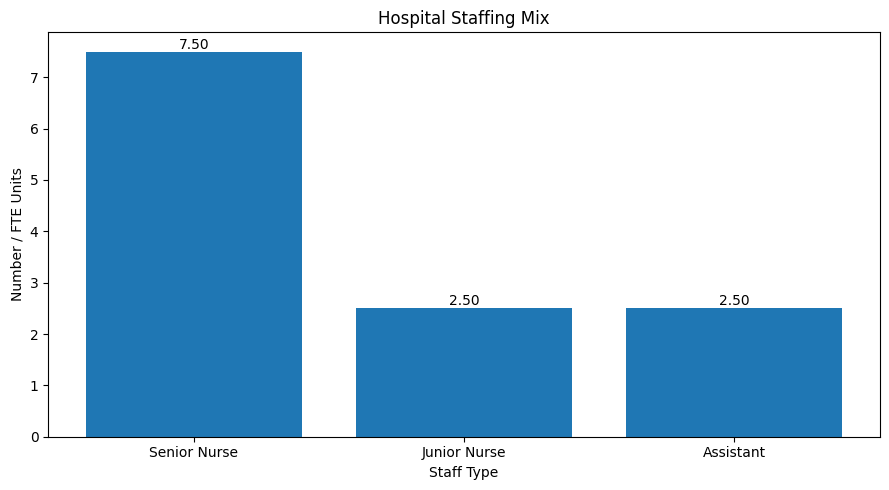

In [ ]:
# ============================================================
# CELL 14: STAFFING MIX BAR CHART
# ============================================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    staff_types,
    solution
)

plt.title("Hospital Staffing Mix")
plt.xlabel("Staff Type")
plt.ylabel("Number / FTE Units")

# Display values above bars
for bar, value in zip(bars, solution):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

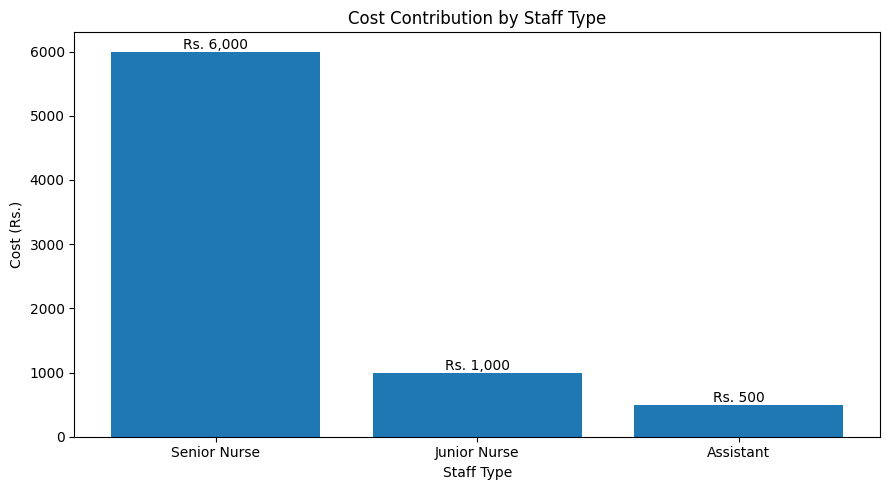

In [ ]:
# ============================================================
# CELL 15: COST CONTRIBUTION CHART
# ============================================================

cost_values = staffing_table["Cost Contribution (Rs.)"]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    staff_types,
    cost_values
)

plt.title("Cost Contribution by Staff Type")
plt.xlabel("Staff Type")
plt.ylabel("Cost (Rs.)")

for bar, value in zip(bars, cost_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"Rs. {value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

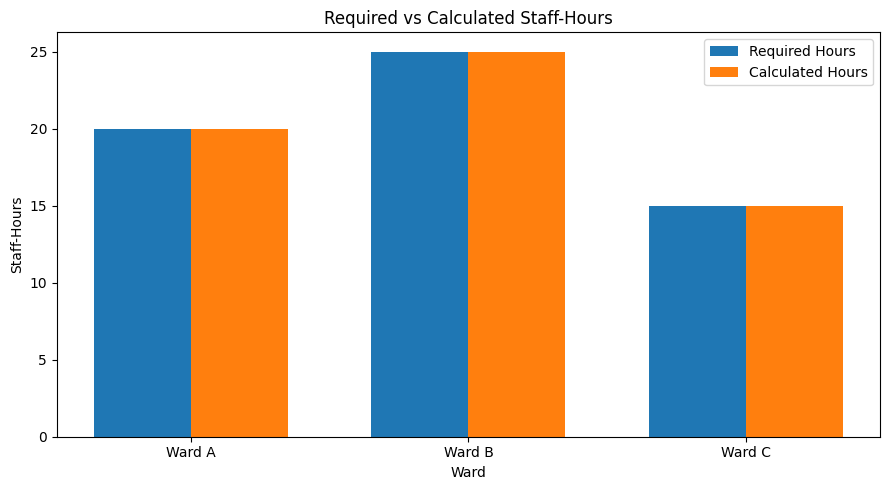

In [ ]:
# ============================================================
# CELL 16: REQUIRED VS CALCULATED HOURS
# ============================================================

x = np.arange(len(wards))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    required_hours,
    width,
    label="Required Hours"
)

plt.bar(
    x + width / 2,
    calculated_B,
    width,
    label="Calculated Hours"
)

plt.xticks(x, wards)
plt.xlabel("Ward")
plt.ylabel("Staff-Hours")
plt.title("Required vs Calculated Staff-Hours")
plt.legend()

plt.tight_layout()
plt.show()

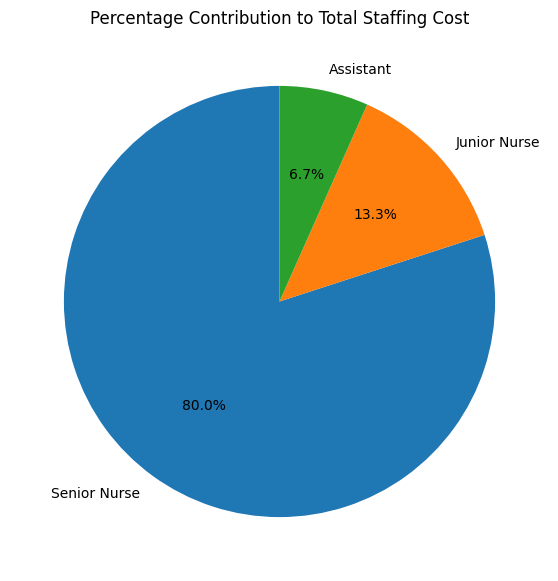

In [ ]:
# ============================================================
# CELL 17: COST DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 7))

plt.pie(
    cost_values,
    labels=staff_types,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Contribution to Total Staffing Cost")

plt.show()

In [ ]:
# ============================================================
# CELL 18: BENCHMARK TEST
# ============================================================

benchmark_A = np.array([
    [1, 2, 3],
    [2, 3, 1],
    [1, 1, 2]
], dtype=float)

benchmark_B = np.array([
    20,
    25,
    15
], dtype=float)

expected_solution = np.array([
    7.5,
    2.5,
    2.5
])

test_solution = gaussian_elimination(
    benchmark_A,
    benchmark_B
)

print("\nExpected solution:")
print(expected_solution)

print("\nCalculated solution:")
print(test_solution)

if np.allclose(test_solution, expected_solution):
    print("\n✓ BENCHMARK TEST PASSED")
else:
    print("\n✗ BENCHMARK TEST FAILED")

Initial Augmented Matrix [A | B]:
[[ 1.  2.  3. 20.]
 [ 2.  3.  1. 25.]
 [ 1.  1.  2. 15.]]

After eliminating column 1:
[[ 2.   3.   1.  25. ]
 [ 0.   0.5  2.5  7.5]
 [ 0.  -0.5  1.5  2.5]]

After eliminating column 2:
[[ 2.   3.   1.  25. ]
 [ 0.   0.5  2.5  7.5]
 [ 0.   0.   4.  10. ]]

After eliminating column 3:
[[ 2.   3.   1.  25. ]
 [ 0.   0.5  2.5  7.5]
 [ 0.   0.   4.  10. ]]

Final solution vector:
[7.5 2.5 2.5]

Expected solution:
[7.5 2.5 2.5]

Calculated solution:
[7.5 2.5 2.5]

✓ BENCHMARK TEST PASSED


In [ ]:
# ============================================================
# CELL 19: PROJECT SUMMARY
# ============================================================

print("""
=============================================================
             HOSPITAL WARD STAFFING OPTIMIZER
=============================================================

Mathematical Model:
    AX = B

Method:
    Gaussian Elimination

Input:
    3 hospital wards
    3 staff types
    Required staff-hours
    Staff-hour contribution matrix
    Cost per staff hour

Output:
    Staffing solution
    Verification of AX = B
    Cost contribution
    Total staffing cost
    Visual charts

Benchmark Result:
    Senior Nurses = 7.50
    Junior Nurses = 2.50
    Assistants    = 2.50

Total Cost:
    Rs. 7,500.00

=============================================================
""")


             HOSPITAL WARD STAFFING OPTIMIZER

Mathematical Model:
    AX = B

Method:
    Gaussian Elimination

Input:
    3 hospital wards
    3 staff types
    Required staff-hours
    Staff-hour contribution matrix
    Cost per staff hour

Output:
    Staffing solution
    Verification of AX = B
    Cost contribution
    Total staffing cost
    Visual charts

Benchmark Result:
    Senior Nurses = 7.50
    Junior Nurses = 2.50
    Assistants    = 2.50

Total Cost:
    Rs. 7,500.00


